In [2]:
# =========================================================
# IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    mean_absolute_error, r2_score,
    classification_report, confusion_matrix
)

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    RandomForestClassifier, GradientBoostingClassifier
)

from xgboost import XGBRegressor, XGBClassifier

import joblib

pd.set_option('display.max_columns', None)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [3]:
# ======================
# LOAD DATASET
# ======================

file_path = "C:\\Users\\Sahil\\Documents\\MY PROJECTS\\AI-Retail-Intelligence-System\\data\\cleaned\\retail_cleaned.csv"

df = pd.read_csv(file_path)

print("Dataset Loaded Successfully")

df.head()

Dataset Loaded Successfully


,date,store_id,product_id,category,region,inventory_level,units_sold,units_ordered,demand_forecast,price,discount,weather_condition,holiday_promotion,competitor_pricing,seasonality,revenue,estimated_profit,demand_gap,price_difference,stock_turnover,inventory_risk,year,month,day,weekday,quarter
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn,4254.50,1063.6250,8.47,3.81,0.549784,Normal,2022,1,1,Saturday,1
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn,9451.50,2362.8750,-5.96,-3.15,0.735294,Normal,2022,1,1,Saturday,1
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer,1819.35,454.8375,9.02,-3.33,0.637255,Normal,2022,1,1,Saturday,1
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn,1995.92,498.9800,1.18,-2.02,0.130064,Normal,2022,1,1,Saturday,1
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer,1030.96,257.7400,-4.74,4.69,0.084337,Normal,2022,1,1,Saturday,1


In [4]:
# =========================================================
# ENCODE CATEGORICAL VARIABLES
# =========================================================

categorical_cols = [
    'category', 'region', 'weather_condition', 'seasonality'
]

le_dict = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

print("Categorical Encoding Completed")

Categorical Encoding Completed


In [6]:
# =========================================================
# REMOVE DATA LEAKAGE
# =========================================================

if 'sales_efficiency' in df.columns:
    df = df.drop(columns=['sales_efficiency'])

print("Leakage Removed")

Leakage Removed


In [7]:
# =========================================================
# FEATURE ENGINEERING
# =========================================================

df['price_ratio'] = df['price'] / (df['competitor_pricing'] + 1)

df['inventory_pressure'] = df['demand_forecast'] / (df['inventory_level'] + 1)

df['discount_effect'] = df['discount'] * df['units_sold']

df['demand_supply_gap'] = df['demand_forecast'] - df['inventory_level']

print("Advanced Features Created")

Advanced Features Created


In [8]:
df = df.drop(columns=[
    'date', 'product_id', 'store_id', 'weekday'
])

## REGRESSION — DEMAND FORECASTING

In [ ]:
# =========================================================
# FEATURE SELECTION
# =========================================================

features = [
    'price', 'discount', 'inventory_level',
    'demand_forecast', 'competitor_pricing',
    'price_difference', 'stock_turnover',
    'price_ratio', 'inventory_pressure',
    'demand_supply_gap',
    'category', 'region', 'seasonality'
]

X = df[features]
y = df['units_sold']

In [ ]:
# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# =========================================================
# DEFINE MODELS
# =========================================================

models_reg = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42)
}

In [13]:
# =========================================================
# HYPERPARAMETER TUNING
# =========================================================

# Random Forest
param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_rf,
    cv=3,
    scoring='r2'
)

grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

# XGBoost
param_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1]
}

grid_xgb = GridSearchCV(
    XGBRegressor(random_state=42),
    param_xgb,
    cv=3,
    scoring='r2'
)

grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_

In [14]:
# =========================================================
# TRAIN & COMPARE
# =========================================================

results = {}

for name, model in models_reg.items():

    if name == "Random Forest":
        model = best_rf

    if name == "XGBoost":
        model = best_xgb

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    r2 = r2_score(y_test, preds)

    results[name] = r2

    print(f"{name} R2:", r2)

Linear Regression R2: 0.9977242064270945
Random Forest R2: 0.9961093991104814
Gradient Boosting R2: 0.9973833042591453
XGBoost R2: 0.9998133182525635


In [ ]:
# =========================================================
# BEST MODEL
# =========================================================

best_model_name = max(results, key=results.get)

print("Best Model:", best_model_name)

best_model_reg = (
    best_rf if best_model_name == "Random Forest"
    else best_xgb if best_model_name == "XGBoost"
    else models_reg[best_model_name]
)

Best Model: XGBoost


In [ ]:
# =========================================================
# CROSS VALIDATION
# =========================================================

cv = cross_val_score(
    best_model_reg,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Final CV Score:", cv.mean())

Final CV Score: 0.9998094320297242


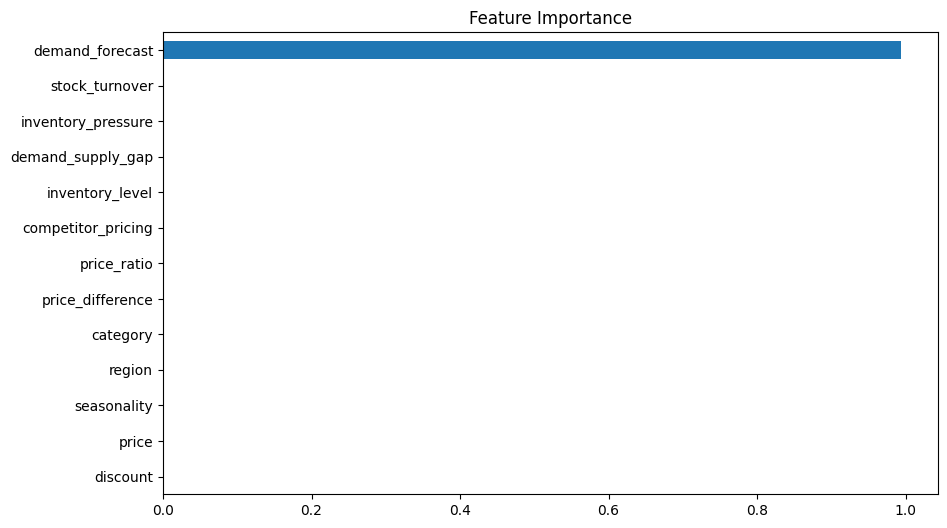

In [ ]:
# =========================================================
# FEATURE IMPORTANCE
# =========================================================

importances = pd.Series(
    best_model_reg.feature_importances_,
    index=X.columns
).sort_values()

plt.figure(figsize=(10,6))
importances.plot(kind='barh')
plt.title("Feature Importance")
plt.show()

## CLASSIFICATION — INVENTORY RISK

In [18]:
# =========================================================
# ENCODE TARGET
# =========================================================

le_target = LabelEncoder()
df['inventory_risk'] = le_target.fit_transform(df['inventory_risk'])

In [19]:
# =========================================================
# SPLIT
# =========================================================

X_cls = df[features]
y_cls = df['inventory_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

In [20]:
# =========================================================
# MODELS
# =========================================================

models_cls = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Random Forest": RandomForestClassifier(
        class_weight='balanced',
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(),

    "XGBoost": XGBClassifier(
        eval_metric='logloss',
        random_state=42
    )
}

In [21]:
# =========================================================
# TUNING
# =========================================================

param_cls = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6]
}

grid_cls = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_cls,
    cv=3,
    scoring='accuracy'
)

grid_cls.fit(X_train, y_train)
best_rf_cls = grid_cls.best_estimator_

In [22]:
# =========================================================
# TRAIN & COMPARE
# =========================================================

results_cls = {}

for name, model in models_cls.items():

    if name == "Random Forest":
        model = best_rf_cls

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    acc = np.mean(preds == y_test)

    results_cls[name] = acc

    print(f"{name} Accuracy:", acc)

Logistic Regression Accuracy: 0.9999309678310092
Random Forest Accuracy: 0.999723871324037
Gradient Boosting Accuracy: 0.9995858069860555
XGBoost Accuracy: 0.9990335496341295


In [23]:
# =========================================================
# BEST CLASSIFIER
# =========================================================

best_model_name_cls = max(results_cls, key=results_cls.get)

print("Best Classifier:", best_model_name_cls)

best_model_cls = (
    best_rf_cls if best_model_name_cls == "Random Forest"
    else models_cls[best_model_name_cls]
)

Best Classifier: Logistic Regression


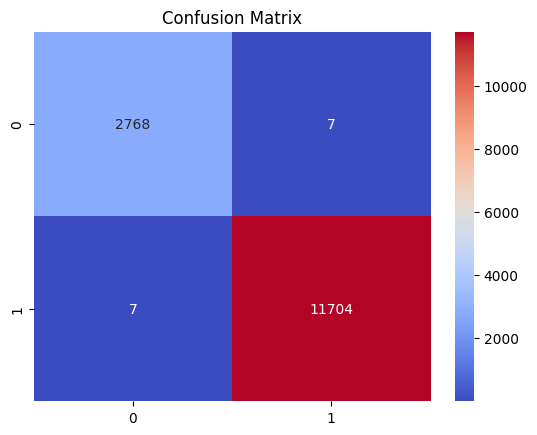

In [24]:
# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(y_test, preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.title("Confusion Matrix")
plt.show()

In [25]:
# =========================================================
# CLASSIFICATION REPORT
# =========================================================

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2775
           1       1.00      1.00      1.00     11711

    accuracy                           1.00     14486
   macro avg       1.00      1.00      1.00     14486
weighted avg       1.00      1.00      1.00     14486



In [ ]:
# =========================================================
# SAVE MODELS
# =========================================================

joblib.dump(best_model_reg, 'C:\\Users\\Sahil\\Documents\\MY PROJECTS\\AI-Retail-Intelligence-System\\models\\best_demand_model.pkl')
joblib.dump(best_model_cls, 'C:\\Users\\Sahil\\Documents\\MY PROJECTS\\AI-Retail-Intelligence-System\\models\\best_risk_model.pkl')
joblib.dump(le_dict, 'C:\\Users\\Sahil\\Documents\\MY PROJECTS\\AI-Retail-Intelligence-System\\models\\label_encoders.pkl')

print("Models Saved Successfully")

Models Saved Successfully
